In [2]:
import os
from collections import defaultdict

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import autoslo.utils.paths as pu
from autoslo.blueprint_selection.query_timeline import QueryTimeline
from autoslo.models.iconq_model import IconqModel
from autoslo.workload_execution.trace import Trace
from matplotlib.lines import Line2D


In [42]:
df = pu.RunLocator.get_runs_df()
df[df['workload_name'] =='benchmarking_workload_99_3_3_shuffled_42']

,run_id,workload_name,num_queries,scale_factor,schema_name,blueprint_name,query_router_name,maxconns,closed_loop
0,1759156767,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_16,RFixed(fixed_cluster_name='cluster_16'),1000,True
1,1759156803,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_32,RFixed(fixed_cluster_name='cluster_32'),1000,True
2,1759156811,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_64,RFixed(fixed_cluster_name='cluster_64'),1000,True
3,1759156817,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_128,RFixed(fixed_cluster_name='cluster_128'),1000,True
4,1759166300,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_256,RFixed(fixed_cluster_name='cluster_256'),1000,True
5,1759429080,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,True
6,1759429111,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_4,RFixed(fixed_cluster_name='cluster_4'),1000,True
112,1767009691,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_32,RFixed(fixed_cluster_name='cluster_32'),1000,True


In [11]:
class IsolatedComparer:

    def __init__(self, iconq_model_id):
        self._real_dict = self._init_real()

        self._iconq_model_id = iconq_model_id
        self._iconq_model = IconqModel.load(iconq_model_id)
        self._iconq_dict_no_fallback = self._init_iconq(False)
        self._iconq_dict_with_fallback = self._init_iconq(True)

        self._stage_dict = self._init_stage()

    def _init_real(self):
        overall_dict = {}

        for rpu in [4, 8, 16, 32, 64, 128, 256]:
            run_ids = pu.RunLocator.get_run_ids(
                workload_name="benchmarking_workload_99_3_3_shuffled_42",
                blueprint_name=f"single_{rpu}",
            )

            rpu_dict = defaultdict(list)

            for run_id in run_ids:
                trace = Trace(run_id)

                # Assert that all the queries are non-overlapping
                start_times_s = trace.arrival_times()
                end_times_s = trace.completion_times()
                most_recent_end_time = pd.Timestamp(0)
                error_msg = (
                    "Query {query_id} starts at {start_time} which is before the most "
                    "recent end time {most_recent_end_time}."
                )
                for query_id in start_times_s.index:
                    start_time = start_times_s[query_id]
                    end_time = end_times_s[query_id]

                    assert start_time >= most_recent_end_time, error_msg.format(
                        query_id=query_id,
                        start_time=start_time,
                        most_recent_end_time=most_recent_end_time,
                    )
                    most_recent_end_time = end_time

                # Collect latencies per (template, query index) and assert each appears 3
                # times
                latencies_s = trace.latencies_s
                tpcds_temp_and_q_idx = trace.tpcds_temp_and_q_idxs
                latencies_per_temp_and_q = defaultdict(list)
                for query_id in latencies_s.index:
                    latency = latencies_s[query_id]
                    temp_and_q_idx = tpcds_temp_and_q_idx[query_id]
                    latencies_per_temp_and_q[temp_and_q_idx].append(latency)
                for item, latencies in latencies_per_temp_and_q.items():
                    assert (
                        len(latencies) == 3
                    ), f"Item {item} appears {len(latencies)} times instead of 3."

                # Add the latencies to the rpu dict
                for item, latencies in latencies_per_temp_and_q.items():
                    rpu_dict[item].extend(latencies)

            overall_dict[rpu] = rpu_dict

        return overall_dict

    def _init_iconq(self, use_stage_for_isolated_queries: bool):
        overall_dict = {}

        for rpu in [4, 8, 16, 32, 64, 128, 256]:
            run_ids = pu.RunLocator.get_run_ids(
                workload_name="benchmarking_workload_99_3_3_shuffled_42",
                blueprint_name=f"single_{rpu}",
            )

            rpu_dict = defaultdict(list)

            for run_id in run_ids:

                trace = Trace(run_id)
                tpcds_temp_and_q_idxs = trace.tpcds_temp_and_q_idxs

                timeline = QueryTimeline(iconq_model=self._iconq_model)
                timeline.initialize_from_trace(trace)

                predictions = timeline.predict_all(
                    use_stage_for_isolated_queries=use_stage_for_isolated_queries
                )

                for (
                    query_id,
                    tpcds_temp_and_q_idx,
                ) in tpcds_temp_and_q_idxs.items():
                    rpu_dict[tpcds_temp_and_q_idx].append(
                        predictions[query_id].overall_mean_s()
                    )

            overall_dict[rpu] = rpu_dict

        return overall_dict

    def _init_stage(self):
        overall_dict = {}

        for rpu in [4, 8, 16, 32, 64, 128, 256]:
            run_ids = pu.RunLocator.get_run_ids(
                workload_name="benchmarking_workload_99_3_3_shuffled_42",
                blueprint_name=f"single_{rpu}",
            )

            rpu_dict = defaultdict(list)

            for run_id in run_ids:

                trace = Trace(run_id)

                for (
                    query_id,
                    tpcds_temp_and_q_idx,
                ) in trace.tpcds_temp_and_q_idxs.items():
                    rpu_dict[tpcds_temp_and_q_idx].append(
                        self._iconq_model.stage_model.predict_from_tpcds_temp_and_q_idx(
                            {query_id: tpcds_temp_and_q_idx},
                            cluster_name=f"cluster_{rpu}",
                        )[
                            query_id
                        ].overall_mean_s()
                    )

            overall_dict[rpu] = rpu_dict

        return overall_dict

    def plot(self, tpcds_temp_and_q_idx):
        data = []

        # Plot a boxplot of the real runtimes
        for rpu, rpu_dict in self._real_dict.items():
            latencies = rpu_dict[tpcds_temp_and_q_idx]
            for latency in latencies:
                data.append({"RPU": rpu, "Latency (s)": latency})
        df = pd.DataFrame(data)
        ax = sns.boxplot(x="RPU", y="Latency (s)", data=df, color="lightblue")

        # Plot scatterpoint of the iconq predictions
        data = []
        for rpu, rpu_dict in self._iconq_dict.items():
            latencies = rpu_dict[tpcds_temp_and_q_idx]
            for latency in latencies:
                data.append({"RPU": rpu, "Latency (s)": latency})
        df = pd.DataFrame(data)
        sns.stripplot(
            x="RPU",
            y="Latency (s)",
            data=df,
            color="red",
            size=8,
            marker="D",
            ax=ax,
        )

        # Plot scatterpoint of the stage predictions
        data = []
        for rpu, rpu_dict in self._stage_dict.items():
            latencies = rpu_dict[tpcds_temp_and_q_idx]
            for latency in latencies:
                data.append({"RPU": rpu, "Latency (s)": latency})
        df = pd.DataFrame(data)
        sns.stripplot(
            x="RPU",
            y="Latency (s)",
            data=df,
            color="green",
            size=8,
            marker="X",
            ax=ax,
        )

        # Add legend
        legend_elements = [
            Line2D(
                [0],
                [0],
                marker="s",
                color="w",
                label="Real Latencies",
                markerfacecolor="lightblue",
                markersize=10,
            ),
            Line2D(
                [0],
                [0],
                marker="D",
                color="w",
                label="Iconq Predictions",
                markerfacecolor="red",
                markersize=10,
            ),
            Line2D(
                [0],
                [0],
                marker="X",
                color="w",
                label="Stage Predictions",
                markerfacecolor="green",
                markersize=10,
            ),
        ]
        ax.legend(handles=legend_elements, loc="upper right")

        ax.set_title(
            f"Latencies for template and query index {tpcds_temp_and_q_idx}"
        )
        ax.set_yscale("log")
        plt.show()

In [12]:
import numpy as np

def plot_errors(comparer, use_stage_for_isolated_queries: bool = False):

    records = []

    for rpu in [4, 8, 16, 32, 64, 128, 256]:
        real_dict = comparer._real_dict[rpu]
        stage_dict = comparer._stage_dict[rpu]
        iconq_dict = (
            comparer._iconq_dict_with_fallback[rpu]
            if use_stage_for_isolated_queries
            else comparer._iconq_dict_no_fallback[rpu]
        )

        for temp_and_q_idx, real_latencies in real_dict.items():
            stage_latencies = stage_dict[temp_and_q_idx]
            stage_latency = np.mean(stage_latencies)

            iconq_latencies = iconq_dict[temp_and_q_idx]
            iconq_latency = np.mean(iconq_latencies)    

            for real_latency in real_latencies:
                stage_rel_error = stage_latency / real_latency
                iconq_rel_error = iconq_latency / real_latency
                records.append(
                    {"RPU": rpu, "Rel Error": stage_rel_error, "Model": "Stage"}
                )
                records.append(
                    {"RPU": rpu, "Rel Error": iconq_rel_error, "Model": "Iconq"}
                )

    df = pd.DataFrame(records)

    ax = sns.boxplot(x="RPU", y="Rel Error", hue="Model", data=df)
    ax.set_yscale("log")
    ax.set_title(
        "Model Relative Error Distribution Across All Templates and Query Indices"
    )

    return ax, df

Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/1767983798/model_1767985867.pth


<Axes: title={'center': 'Model Relative Error Distribution Across All Templates and Query Indices'}, xlabel='RPU', ylabel='Rel Error'>

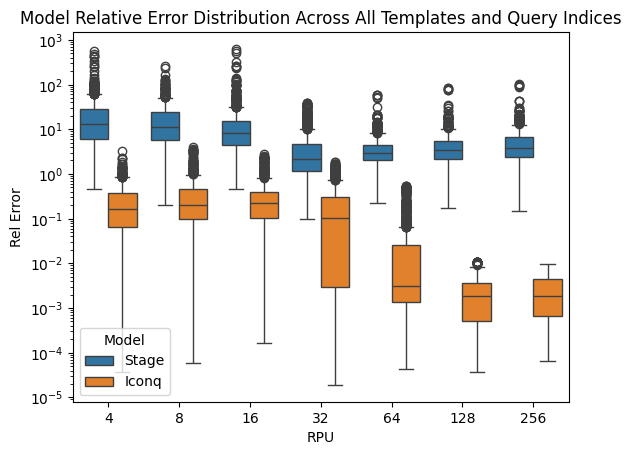

In [8]:
comparer_1 = IsolatedComparer(iconq_model_id='1767983798')
ax, df = plot_errors(comparer_1)
ax

Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/1768080208/model_1768083625.pth


<Axes: title={'center': 'Model Relative Error Distribution Across All Templates and Query Indices'}, xlabel='RPU', ylabel='Rel Error'>

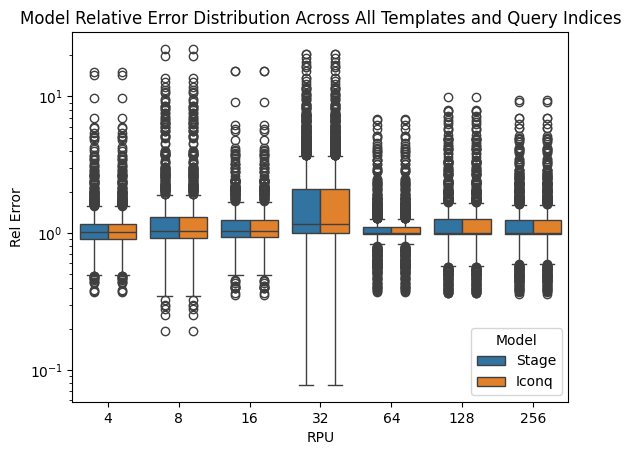

In [15]:
comparer_2 = IsolatedComparer(iconq_model_id='1768080208')
ax2, df2 = plot_errors(comparer_2, use_stage_for_isolated_queries=True)
ax2

In [86]:
run_id = pu.RunLocator.get_run_ids(workload_name='tpcds_99templates_25pctheavy_60meaninterarrivals', blueprint_name='single_8', schema_name='ext')
run_id

['1763282030']

In [89]:
trace = Trace(run_id[0])
trace.arrival_times()

query_id
cluster_8_5486021#58bc5210-ca4d-4141-b6d8-16ad50ea4fae   2025-11-16 08:37:12.962819
cluster_8_5486026#58bc5210-ca4d-4141-b6d8-16ad50ea4fae   2025-11-16 08:37:14.948410
cluster_8_5486031#58bc5210-ca4d-4141-b6d8-16ad50ea4fae   2025-11-16 08:37:15.162556
cluster_8_5486048#58bc5210-ca4d-4141-b6d8-16ad50ea4fae   2025-11-16 08:37:31.603149
cluster_8_5486107#58bc5210-ca4d-4141-b6d8-16ad50ea4fae   2025-11-16 08:38:47.914330
                                                                    ...            
cluster_8_5488250#58bc5210-ca4d-4141-b6d8-16ad50ea4fae   2025-11-16 09:29:23.119065
cluster_8_5488316#58bc5210-ca4d-4141-b6d8-16ad50ea4fae   2025-11-16 09:31:04.112642
cluster_8_5488379#58bc5210-ca4d-4141-b6d8-16ad50ea4fae   2025-11-16 09:32:39.201249
cluster_8_5488388#58bc5210-ca4d-4141-b6d8-16ad50ea4fae   2025-11-16 09:32:45.687019
cluster_8_5488418#58bc5210-ca4d-4141-b6d8-16ad50ea4fae   2025-11-16 09:33:38.389774
Name: start_time, Length: 63, dtype: datetime64[ns]